# Baseline Models - Logistic Regression and SVM

# Import Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
from sklearn.feature_extraction.text import CountVectorizer
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

count=CountVectorizer()

# Load Data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

file_path = '/content/drive/My Drive/BT4222/data/df_feature_engineering.parquet'
df = pd.read_parquet(file_path)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,id,label,statement,subject,speaker,speaker_job_title,state_info,party_affiliation,barely_true_counts,false_counts,...,label_pants-fire,label_true,statement_embedding,subject_embedding,state_info_encoded,party_affiliation_encoded,speaker_job_title_embedding,context_embedding,sentiment_polarity,sentiment_subjectivity
0,7874.json,half-true,new jersey pension system solvent,"pensions,state-finances",13th district gop slate,unknown,new jersey,republican,0.0,0.0,...,0,0,"[-0.012083505280315876, 0.04291439801454544, -...","[-0.00025620736414566636, 0.07373839616775513,...",31,8,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.09551206976175308, 0.009169962257146835, 0...",0.136364,0.455
1,2287.json,pants-fire,president obama muslim,"candidates-biography,obama-birth-certificate,r...",18 percent american public,unknown,unknown,other,0.0,0.0,...,1,0,"[0.038615476340055466, 0.09793295711278915, -0...","[0.018359245732426643, -0.0027450439520180225,...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.024317895993590355, -0.01789085566997528, ...",0.000000,0.000
2,13412.json,true,test share fact widget,technology,18 percent american public,unknown,unknown,other,0.0,0.0,...,0,1,"[0.008107000961899757, 0.016036679968237877, -...","[-0.053375788033008575, 0.08707486093044281, -...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.06791266053915024, -0.015540316700935364, ...",0.000000,0.000
3,2426.json,barely-true,new health care law cut billion medicare hurt ...,"health-care,medicare,message-machine",60 plus association,unknown,unknown,other,2.0,0.0,...,0,0,"[-0.05084792524576187, 0.031769607216119766, 0...","[-0.01470591127872467, 0.015529205091297626, 0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.10175436735153198, -0.002838208107277751, ...",0.136364,0.455
4,4832.json,pants-fire,independent payment advisory board created hea...,"government-regulation,health-care,message-mach...",60 plus association,unknown,unknown,other,2.0,0.0,...,1,0,"[-0.10781728476285934, 0.017993967980146408, 0...","[0.02528245933353901, 0.005831953138113022, -0...",45,7,"[-0.043102607131004333, 0.06563703715801239, -...","[-0.03631351888179779, 0.039651136845350266, -...",0.068182,0.290


## Label Encoding
Here, we encode the labels where
- 0: 'pants-fire'
- 1: 'false'
- 2: 'barely-true'
- 3: 'half-true'
- 4: 'mostly-true'
- 5: 'true'

In [ ]:
label_order = ['pants-fire', 'false', 'barely-true', 'half-true', 'mostly-true', 'true']
label2idx = {label: idx for idx, label in enumerate(label_order)}
idx2label = {idx: label for label, idx in label2idx.items()}
df['label_encoded'] = df['label'].map(label2idx)

## Encoding the speaker

- Here, we further do feature engineering by encoding the speaker column into numerical values

In [ ]:
le = LabelEncoder()
df['speaker_encoded'] = le.fit_transform(df['speaker'])

### Concatenate all features and inputting into a single input matrix X_all

In [ ]:
# converting into array
statement_embeddings = np.array(df['statement_embedding'].tolist())
subject_embeddings = np.array(df['subject_embedding'].tolist())
state_info_encoded = np.array(df['state_info_encoded'].tolist())
speaker_encoded = np.array(df['speaker_encoded'].tolist())
party_affiliation_encoded = np.array(df['party_affiliation_encoded'].tolist())
speaker_job_title_embeddings = np.array(df['speaker_job_title_embedding'].tolist())
context_embeddings = np.array(df['context_embedding'].tolist())

# ensure that encodings have the correct shape
state_info_encoded = state_info_encoded.reshape(-1, 1)
party_affiliation_encoded = party_affiliation_encoded.reshape(-1, 1)
speaker_encoded = speaker_encoded.reshape(-1, 1)

In [ ]:
X_all = np.concatenate([
    statement_embeddings,
    subject_embeddings,
    speaker_encoded,
    speaker_job_title_embeddings,
    state_info_encoded.reshape(-1, 1),
    party_affiliation_encoded.reshape(-1, 1),
    context_embeddings
], axis=1)

X_all

array([[-0.01208351,  0.0429144 , -0.07741898, ...,  0.00556437,
        -0.05086416,  0.03572651],
       [ 0.03861548,  0.09793296, -0.01990953, ..., -0.07543088,
        -0.03735333,  0.03248962],
       [ 0.008107  ,  0.01603668, -0.03262832, ..., -0.00322393,
         0.00075328,  0.04445644],
       ...,
       [ 0.03097461,  0.0335738 , -0.02625445, ...,  0.03542946,
         0.10346109,  0.04180447],
       [ 0.00427243,  0.05442103,  0.0293391 , ...,  0.00656702,
         0.00102223, -0.01387688],
       [-0.04202396,  0.06849299,  0.00182957, ...,  0.10263272,
         0.03166698,  0.04968008]])

In [ ]:
y = df['label_encoded']
y.head()

,label_encoded
0,3
1,0
2,5
3,2
4,0


## Splitting the dataset into train and test

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_all, y, test_size=0.2, random_state=42)

# check if the shapes are correct
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(10228, 1539) (2558, 1539) (10228,) (2558,)


# Train models for All Columns as input

## Scaling X columns

We scale the input columns as embedding and encoding columns have very different ranges. Since Logistic Regression and SVM are sensitive to feature ranges, we scale them to ensure that features with larger ranges will not disproportionately influence the results, and for the models to converge faster and more reliably.

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Logistic Loss

here, we used a logistic regression model using stochastic gradient descent on the scaled training data to predict class labels.

In [ ]:
clf= SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0001, fit_intercept=True,
                   max_iter=1000, tol=0.001, shuffle=True, verbose=0, n_jobs=None,
                   random_state=None, learning_rate='optimal', early_stopping=False,
                   class_weight=None, warm_start=False, average=False)

clf.fit(X_train_scaled, y_train)

# predict on the train set
y_train_pred = clf.predict(X_train_scaled)

# predict on the test set
y_pred = clf.predict(X_test_scaled)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


### Evaluation metrics for Train Set

Training Set Evaluation
Accuracy: 0.41112631990614
Precision (macro): 0.4293486302977141
Recall (macro): 0.41812641131507894
F1-score (macro): 0.4224198312811714
Confusion Matrix:
 [[409 138 102  80  57  55]
 [ 90 871 264 291 227 275]
 [ 53 304 633 238 204 228]
 [ 53 336 261 809 320 313]
 [ 55 302 193 320 777 318]
 [ 42 239 160 294 211 706]]


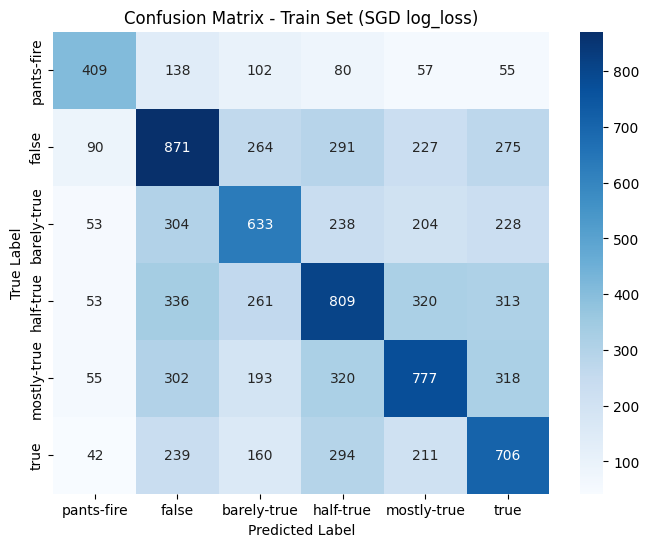


Classification Report (Train Set):
              precision    recall  f1-score   support

           0     0.5826    0.4863    0.5301       841
           1     0.3977    0.4316    0.4140      2018
           2     0.3924    0.3813    0.3868      1660
           3     0.3981    0.3867    0.3923      2092
           4     0.4326    0.3954    0.4132      1965
           5     0.3726    0.4274    0.3981      1652

    accuracy                         0.4111     10228
   macro avg     0.4293    0.4181    0.4224     10228
weighted avg     0.4148    0.4111    0.4120     10228



In [ ]:
print("Training Set Evaluation")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision (macro):", precision_score(y_train, y_train_pred, average='macro'))
print("Recall (macro):", recall_score(y_train, y_train_pred, average='macro'))
print("F1-score (macro):", f1_score(y_train, y_train_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

# Confusion Matrix Heatmap for Train Set
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix - Train Set (SGD log_loss)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\nClassification Report (Train Set):")
print(classification_report(y_train, y_train_pred, digits=4))

### Evaluation metrics for Test Set


Test Set Evaluation
Accuracy: 0.21853010164190775
Precision (macro): 0.2159412461231828
Recall (macro): 0.21956021078740373
F1-score (macro): 0.21693749641195645
Confusion Matrix:
 [[ 48  49  39  31  22  17]
 [ 57 129  83  69  67  81]
 [ 36 109  77  91  62  67]
 [ 37 124  81  98 108  87]
 [ 29  79  63  87 123 108]
 [ 32  68  41  92  83  84]]


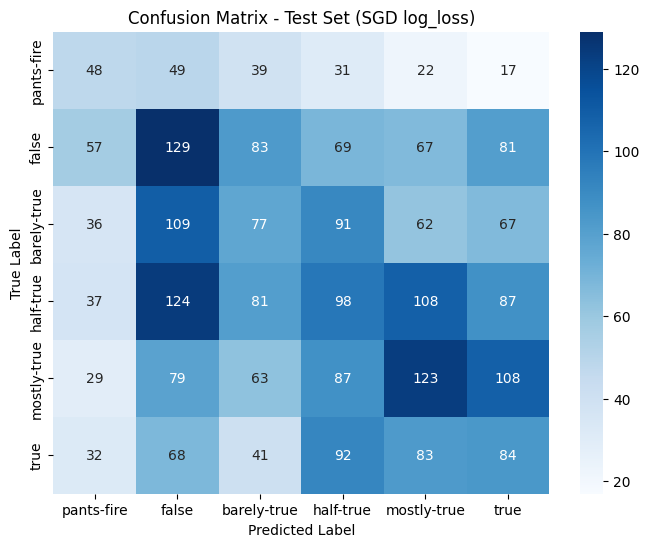


Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.2008    0.2330    0.2157       206
           1     0.2312    0.2654    0.2471       486
           2     0.2005    0.1742    0.1864       442
           3     0.2094    0.1832    0.1954       535
           4     0.2645    0.2515    0.2579       489
           5     0.1892    0.2100    0.1991       400

    accuracy                         0.2185      2558
   macro avg     0.2159    0.2196    0.2169      2558
weighted avg     0.2187    0.2185    0.2178      2558



In [ ]:
print("\nTest Set Evaluation")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Confusion Matrix Heatmap for Test Set
cm_test = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix - Test Set (SGD log_loss)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, digits=4))

## SVM

In [ ]:
clf = SGDClassifier(loss='hinge', penalty='l2', alpha=0.0001, fit_intercept=True,
                    max_iter=1000, tol=0.001, shuffle=True, verbose=0,
                    learning_rate='optimal', early_stopping=False,
                    n_iter_no_change=5, class_weight=None, warm_start=False, average=False)

clf.fit(X_train_scaled, y_train)

y_train_pred = clf.predict(X_train_scaled)
y_pred = clf.predict(X_test_scaled)

/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


### Evaluation metrics for Train Set

Training Set Evaluation (SVM)
Accuracy: 0.4222721939773172
Precision (macro): 0.4418101149755003
Recall (macro): 0.4297973542550197
F1-score (macro): 0.4343898195821992
Confusion Matrix:
 [[443 139  73  57  65  64]
 [ 94 923 229 337 236 199]
 [ 58 357 603 293 206 143]
 [ 55 367 230 940 286 214]
 [ 53 285 214 431 741 241]
 [ 36 251 164 298 234 669]]


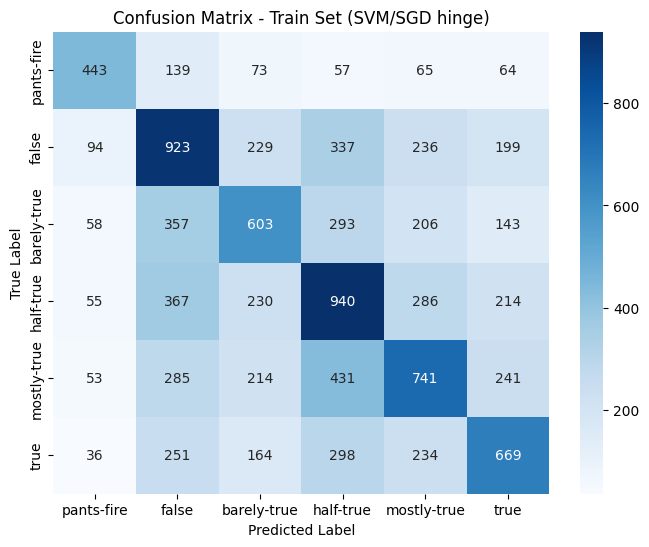


Classification Report (Train Set):
              precision    recall  f1-score   support

           0     0.5995    0.5268    0.5608       841
           1     0.3975    0.4574    0.4253      2018
           2     0.3985    0.3633    0.3801      1660
           3     0.3990    0.4493    0.4227      2092
           4     0.4191    0.3771    0.3970      1965
           5     0.4373    0.4050    0.4205      1652

    accuracy                         0.4223     10228
   macro avg     0.4418    0.4298    0.4344     10228
weighted avg     0.4252    0.4223    0.4224     10228



In [ ]:
print("Training Set Evaluation (SVM)")
print("Accuracy:", accuracy_score(y_train, y_train_pred))
print("Precision (macro):", precision_score(y_train, y_train_pred, average='macro'))
print("Recall (macro):", recall_score(y_train, y_train_pred, average='macro'))
print("F1-score (macro):", f1_score(y_train, y_train_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_train, y_train_pred))

# Confusion Matrix Heatmap for Train Set
cm_train = confusion_matrix(y_train, y_train_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix - Train Set (SVM/SGD hinge)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\nClassification Report (Train Set):")
print(classification_report(y_train, y_train_pred, digits=4))

### Evaluation Metrics for Test Set


Test Set Evaluation (SVM)
Accuracy: 0.22165754495699766
Precision (macro): 0.21748637057305076
Recall (macro): 0.219545218339343
F1-score (macro): 0.21789739403359223
Confusion Matrix:
 [[ 42  42  41  26  31  24]
 [ 62 126  61  95  74  68]
 [ 38 112  79  89  68  56]
 [ 35 129  72 129 102  68]
 [ 25  88  71 114  95  96]
 [ 31  64  51  81  77  96]]


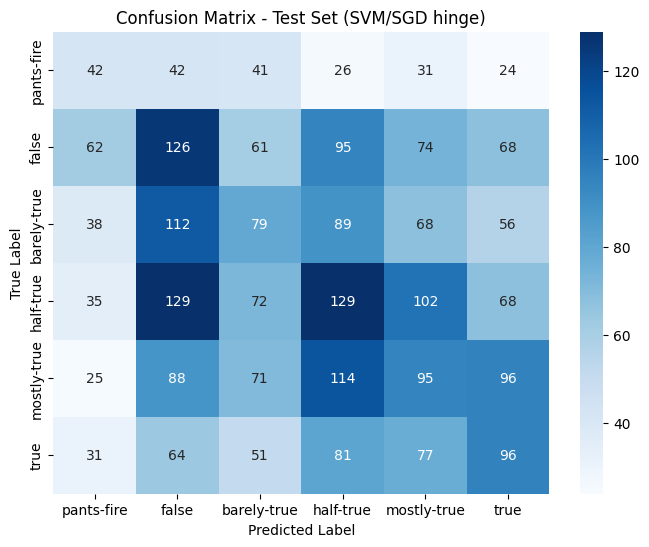


Classification Report (Test Set):
              precision    recall  f1-score   support

           0     0.1803    0.2039    0.1913       206
           1     0.2246    0.2593    0.2407       486
           2     0.2107    0.1787    0.1934       442
           3     0.2416    0.2411    0.2413       535
           4     0.2125    0.1943    0.2030       489
           5     0.2353    0.2400    0.2376       400

    accuracy                         0.2217      2558
   macro avg     0.2175    0.2195    0.2179      2558
weighted avg     0.2215    0.2217    0.2210      2558



In [ ]:
print("\nTest Set Evaluation (SVM)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision (macro):", precision_score(y_test, y_pred, average='macro'))
print("Recall (macro):", recall_score(y_test, y_pred, average='macro'))
print("F1-score (macro):", f1_score(y_test, y_pred, average='macro'))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Confusion Matrix Heatmap for Test Set
cm_test = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues',
            xticklabels=label_order, yticklabels=label_order)
plt.title("Confusion Matrix - Test Set (SVM/SGD hinge)")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

print("\nClassification Report (Test Set):")
print(classification_report(y_test, y_pred, digits=4))

### Explanation and Comparison for the Models

Overall, both Logistic Regression and SVM yielded similar results, reflecting the limitations of linear models for this task. This suggests that the data may not be linearly separable and could benefit from more complex features or non-linear models. Nevertheless, these models serve as strong baselines for benchmarking improvements achieved through our ensemble approach.
